# OCR Evaluation (EasyOCR)

So sánh OCR accuracy bằng **EasyOCR** trên các phương pháp scan/binarization.


## Phương pháp scan so sánh

1. **original** — vùng tương ứng trên ảnh gốc (vẫn méo perspective) — baseline
2. **warped_gray** — vùng crop trên ảnh warped, xám
3. **otsu** — Otsu thresholding
4. **adaptive** — Adaptive Gaussian threshold
5. **clahe_otsu** — CLAHE + Otsu
6. **color** — Color-preserving (background division)


## Cách chạy

1. Chạy cell **Đọc dữ liệu từ kaggle** để tải dữ liệu từ kaggle.
2. Chạy lần lượt các cell còn lại.

In [2]:
%pip install -q easyocr python-Levenshtein

import torch
import easyocr

print("EasyOCR version:", easyocr.__version__)
print("Torch version  :", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU device    :", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.9 MB/s eta 0:00:00
EasyOCR version: 1.7.2
Torch version  : 2.10.0+cu128
CUDA available: True
GPU device    : Tesla T4


In [3]:
import json
import re
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from Levenshtein import distance, ratio


## 1. Đọc data từ kaggle

In [ ]:
import os
from google.colab import files


!rm -rf ~/.cache/kaggle
!rm -rf /content/dataset

!kaggle datasets download -d tiendq/scanner --force
!unzip -q scanner.zip -d /content

In [ ]:
EVAL_DIR = Path('/content/dataset/test/eval_run')
WARPED_DIR = EVAL_DIR / 'warped'
TRANSFORMS_DIR = EVAL_DIR / 'transforms'
OCR_GT_PATH = EVAL_DIR / 'ocr_gt.json'
ORIGINAL_DIR = Path('/content/dataset/test')

RESULTS_CSV = EVAL_DIR / 'ocr_results_easyocr.csv'
SUMMARY_CSV = EVAL_DIR / 'ocr_summary_easyocr.csv'

ENGINE_NAME = 'easyocr'
TMP_OCR_DIR = EVAL_DIR / '_tmp_easyocr_inputs'
TMP_OCR_DIR.mkdir(parents=True, exist_ok=True)

print('EVAL_DIR    :', EVAL_DIR)
print('ORIGINAL_DIR:', ORIGINAL_DIR)
print('ENGINE_NAME :', ENGINE_NAME)
print('TMP_OCR_DIR :', TMP_OCR_DIR)


## 2. Đọc data từ drive

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# EVAL_DIR = Path('/content/drive/MyDrive/CV/pr/dataset/test/eval_run')
# WARPED_DIR = EVAL_DIR / 'warped'
# TRANSFORMS_DIR = EVAL_DIR / 'transforms'
# OCR_GT_PATH = EVAL_DIR / 'ocr_gt.json'
# ORIGINAL_DIR = Path('/content/drive/MyDrive/CV/pr/dataset/test')

# RESULTS_CSV = EVAL_DIR / 'ocr_results_easyocr.csv'
# SUMMARY_CSV = EVAL_DIR / 'ocr_summary_easyocr.csv'

# ENGINE_NAME = 'easyocr'
# TMP_OCR_DIR = EVAL_DIR / '_tmp_easyocr_inputs'
# TMP_OCR_DIR.mkdir(parents=True, exist_ok=True)

# print('EVAL_DIR    :', EVAL_DIR)
# print('ORIGINAL_DIR:', ORIGINAL_DIR)
# print('ENGINE_NAME :', ENGINE_NAME)
# print('TMP_OCR_DIR :', TMP_OCR_DIR)


EVAL_DIR    : /content/drive/MyDrive/CV/pr/dataset/test/eval_run
ORIGINAL_DIR: /content/drive/MyDrive/CV/pr/dataset/test
ENGINE_NAME : easyocr
TMP_OCR_DIR : /content/drive/MyDrive/CV/pr/dataset/test/eval_run/_tmp_easyocr_inputs


## 3. Load ground truth

In [7]:
with open(OCR_GT_PATH, encoding='utf-8') as f:
    gt_data = json.load(f)

CROP_REGION = tuple(gt_data['crop_region'])
items = gt_data['items']
print(f'Ground truth có {len(items)} ảnh, crop_region = {CROP_REGION}\n')
for stem, info in items.items():
    print(f'  {stem}: {info["ground_truth"][:60]}...')

Ground truth có 18 ảnh, crop_region = (0.05, 0.06, 0.95, 0.16)

  z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26: I’ve always been keen on sport and very fit so a few years a...
  z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd: Điều khoản liên quan tới chương trình máy chương trình máy t...
  z7714827138018_2c6a64a819a53f7c09698670d1d0c3c3: Điều khoản liên quan tới chương trình máy chương trình máy t...
  z7714827142264_5ac4f8f41b14a8f38425b0c2e7bf576e: Điều khoản liên quan tới chương trình máy chương trình máy t...
  z7714827176964_651ecba060792771a088a276a71224c6: Thời gian Đầm thuận kiếm được. Đồng thời họ cũng hi vọng “mộ...
  2aOboQY0LBwLs4o8LQpYJ31H0OSflP7tBBHsTLTE: Output: chuyển thành thập phân ta tạo biến acc = 0 duyệt từ ...
  2aOboQY0LEFxDH3abPqjshfixAFuRAaJTAJ5BjiC: Hoa – Việt thân thiện đối với quân đội Tưởng Giới Thạch và v...
  2aOboQY0L8fcafZOXWcTbRm76XS8xGc87Tpt8AcK: Thực hiện kế hoạc rơve, từ tháng 6/1949 Pháp đưa nhiều vũ kh...
  z7722644494144_618dbae640d2900065f9

## 4. Hàm tiện ích

### 4.1. Crop & inverse map

In [8]:
def warped_bbox_to_original_quad(bbox_warped, M):
    """bbox_warped = (x0, y0, x1, y1) trên ảnh warped → 4 điểm trên ảnh gốc."""
    x0, y0, x1, y1 = bbox_warped
    pts = np.array([
        [x0, y0], [x1, y0], [x1, y1], [x0, y1]
    ], dtype=np.float32).reshape(-1, 1, 2)
    M_inv = np.linalg.inv(np.asarray(M, dtype=np.float64))
    out = cv2.perspectiveTransform(pts, M_inv)
    return out.reshape(4, 2)


def crop_quad_bbox_on_original(img, quad):
    """Bounding box bao quanh quad trên ảnh gốc — GIỮ méo perspective."""
    quad = np.asarray(quad).reshape(4, 2)
    x_min, y_min = quad.min(axis=0)
    x_max, y_max = quad.max(axis=0)
    H, W = img.shape[:2]
    x_min = max(0, int(np.floor(x_min)))
    y_min = max(0, int(np.floor(y_min)))
    x_max = min(W, int(np.ceil(x_max)))
    y_max = min(H, int(np.ceil(y_max)))
    return img[y_min:y_max, x_min:x_max]

### 4.2. Các phương pháp binarization/enhancement

In [9]:
def to_gray(img):
    if len(img.shape) == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img.copy()


def apply_otsu(img):
    gray = to_gray(img)
    _, out = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return out


def apply_adaptive(img, block_size=21, C=8):
    gray = to_gray(img)
    return cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block_size, C,
    )


def apply_clahe_otsu(img, clip_limit=2.0, tile_grid=(8, 8)):
    gray = to_gray(img)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    enhanced = clahe.apply(gray)
    _, out = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return out


def color_preserving_scan(img_bgr):
    """Background division — giữ màu, làm nền trắng đều."""
    if len(img_bgr.shape) == 2:
        img_bgr = cv2.cvtColor(img_bgr, cv2.COLOR_GRAY2BGR)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    bg = cv2.dilate(gray, np.ones((7, 7), np.uint8))
    bg = cv2.medianBlur(bg, 21)
    bg_3ch = cv2.cvtColor(bg, cv2.COLOR_GRAY2BGR).astype(np.float32)
    diff = img_bgr.astype(np.float32) / np.maximum(bg_3ch, 1) * 255
    return np.clip(diff, 0, 255).astype(np.uint8)


def get_variant(name, warped_crop_bgr):
    if name == 'warped_gray':
        return to_gray(warped_crop_bgr)
    if name == 'otsu':
        return apply_otsu(warped_crop_bgr)
    if name == 'adaptive':
        return apply_adaptive(warped_crop_bgr)
    if name == 'clahe_otsu':
        return apply_clahe_otsu(warped_crop_bgr)
    if name == 'color':
        return color_preserving_scan(warped_crop_bgr)
    raise ValueError(f'Unknown variant: {name}')


VARIANTS = ['warped_gray', 'otsu', 'adaptive', 'clahe_otsu', 'color']
ALL_VARIANTS = ['original'] + VARIANTS

### 4.3. EasyOCR + Metric


In [10]:
# Khởi tạo EasyOCR một lần duy nhất để tránh load model lại nhiều lần.
# Lần chạy đầu tiên có thể mất thời gian vì EasyOCR tự tải model pretrained.
USE_GPU = True
EASYOCR_LANGS = ['vi', 'en']

reader = easyocr.Reader(
    EASYOCR_LANGS,
    gpu=USE_GPU,
    verbose=True,
)


def _save_img_for_ocr(img, stem='tmp', variant='image'):
    """Lưu crop thành file tạm để EasyOCR đọc ổn định trên Colab."""
    if img is None or img.size == 0:
        return None

    safe_stem = re.sub(r'[^a-zA-Z0-9_\-]+', '_', str(stem))
    safe_variant = re.sub(r'[^a-zA-Z0-9_\-]+', '_', str(variant))
    out_path = TMP_OCR_DIR / f'{safe_stem}_{safe_variant}.png'

    # cv2.imwrite nhận BGR hoặc grayscale đều được.
    cv2.imwrite(str(out_path), img)
    return out_path


def _extract_texts_from_easyocr_result(result, min_confidence=0.0):
    """EasyOCR trả về list: [(bbox, text, confidence), ...]."""
    texts = []
    if result is None:
        return texts

    for item in result:
        try:
            # detail=1: item = (bbox, text, conf)
            if isinstance(item, (list, tuple)) and len(item) >= 2:
                text = item[1]
                conf = item[2] if len(item) >= 3 else 1.0
                if conf is None:
                    conf = 1.0
                if float(conf) >= min_confidence and str(text).strip():
                    texts.append(str(text))
            # detail=0: item = text
            elif isinstance(item, str) and item.strip():
                texts.append(item)
        except Exception:
            pass
    return texts


def run_easyocr(img, stem='tmp', variant='image', min_confidence=0.0):
    if img is None or img.size == 0:
        return ''

    img_path = _save_img_for_ocr(img, stem=stem, variant=variant)
    if img_path is None:
        return ''

    try:
        result = reader.readtext(
            str(img_path),
            detail=1,
            paragraph=False,
            decoder='greedy',
            batch_size=1,
        )
        texts = _extract_texts_from_easyocr_result(result, min_confidence=min_confidence)
        return ' '.join(texts)
    except Exception as e:
        print(f'  [easyocr error] {e}')
        return ''


def normalize(text):
    text = (text or '').replace('\n', ' ').replace('\r', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def char_accuracy(pred, gt):
    return ratio(normalize(pred), normalize(gt))


def cer(pred, gt):
    p, g = normalize(pred), normalize(gt)
    if not g:
        return 0.0
    return distance(p, g) / len(g)


def word_accuracy(pred, gt):
    p_words = normalize(pred).lower().split()
    g_words = normalize(gt).lower().split()
    if not g_words:
        return 0.0

    pool = list(p_words)
    correct = 0
    for w in g_words:
        if w in pool:
            correct += 1
            pool.remove(w)
    return correct / len(g_words)


def all_metrics(pred, gt):
    return {
        'char_acc': char_accuracy(pred, gt),
        'cer': cer(pred, gt),
        'word_acc': word_accuracy(pred, gt),
    }


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

## 5. Helper: chuẩn bị các crop cho 1 ảnh

In [11]:
def find_original(stem):
    for ext in ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'):
        p = ORIGINAL_DIR / f'{stem}{ext}'
        if p.exists():
            return p
    matches = list(ORIGINAL_DIR.glob(f'{stem}.*'))
    return matches[0] if matches else None


def prepare_crops(stem, info):
    """Trả về dict {variant_name: image} cho 1 ảnh."""
    crops = {}

    warped_path = WARPED_DIR / f'{stem}.jpg'
    warped = cv2.imread(str(warped_path))
    if warped is None:
        return None

    crop_pixel = info['crop_pixel']
    x0, y0, x1, y1 = crop_pixel
    warped_crop = warped[y0:y1, x0:x1]

    # original via M^-1
    transform_path = TRANSFORMS_DIR / f'{stem}.json'
    if transform_path.exists():
        with open(transform_path) as f:
            tdata = json.load(f)
        M = np.array(tdata['M'], dtype=np.float64)
        original_path = find_original(stem)
        if original_path is not None:
            original = cv2.imread(str(original_path))
            quad = warped_bbox_to_original_quad((x0, y0, x1, y1), M)
            crops['original'] = crop_quad_bbox_on_original(original, quad)

    for vname in VARIANTS:
        crops[vname] = get_variant(vname, warped_crop)

    return crops

## 6. Chạy evaluation

Loop qua từng ảnh × từng variant → DataFrame.

In [12]:
rows = []
predictions_cache = {}

for stem, info in items.items():
    print(f'\n=== {stem} ===')
    gt_text = info['ground_truth']

    crops = prepare_crops(stem, info)
    if crops is None:
        print('  [skip] không chuẩn bị được crop')
        continue
    predictions_cache[stem] = {'crops': crops, 'preds': {}}

    for variant in ALL_VARIANTS:
        img = crops.get(variant)
        if img is None or img.size == 0:
            print(f'  [skip] {variant}: empty crop')
            continue

        pred = run_easyocr(img, stem=stem, variant=variant)
        metrics = all_metrics(pred, gt_text)
        rows.append({
            'stem': stem,
            'variant': variant,
            'engine': ENGINE_NAME,
            'pred': pred.strip(),
            'gt': gt_text,
            **metrics,
        })
        predictions_cache[stem]['preds'][variant] = pred
        print(f"  {variant:14s} char_acc={metrics['char_acc']:.3f}  cer={metrics['cer']:.3f}  word_acc={metrics['word_acc']:.3f}")

df = pd.DataFrame(rows)
df.to_csv(RESULTS_CSV, index=False)
print(f'\nLưu kết quả → {RESULTS_CSV}')
df.head(20)



=== z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26 ===
  original       char_acc=0.932  cer=0.116  word_acc=0.788
  warped_gray    char_acc=0.915  cer=0.154  word_acc=0.818
  otsu           char_acc=0.793  cer=0.276  word_acc=0.455
  adaptive       char_acc=0.848  cer=0.214  word_acc=0.545
  clahe_otsu     char_acc=0.884  cer=0.175  word_acc=0.652
  color          char_acc=0.960  cer=0.065  word_acc=0.833

=== z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd ===
  original       char_acc=0.294  cer=0.889  word_acc=0.000
  warped_gray    char_acc=0.325  cer=0.821  word_acc=0.030
  otsu           char_acc=0.324  cer=0.833  word_acc=0.000
  adaptive       char_acc=0.281  cer=0.840  word_acc=0.030
  clahe_otsu     char_acc=0.294  cer=0.846  word_acc=0.030
  color          char_acc=0.380  cer=0.772  word_acc=0.030

=== z7714827138018_2c6a64a819a53f7c09698670d1d0c3c3 ===
  original       char_acc=0.287  cer=0.864  word_acc=0.000
  warped_gray    char_acc=0.295  cer=0.790  word_acc=0.000
  o

,stem,variant,engine,pred,gt,char_acc,cer,word_acc
0,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,original,easyocr,Fve ahwvays been on1 sport very fit so few yea...,I’ve always been keen on sport and very fit so...,0.932331,0.115727,0.787879
1,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,warped_gray,easyocr,Fve alwvays been keen on sport and very fit so...,I’ve always been keen on sport and very fit so...,0.914543,0.154303,0.818182
2,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,otsu,easyocr,F've always bccn kccn on sport and vcry [il so...,I’ve always been keen on sport and very fit so...,0.792738,0.275964,0.454545
3,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,adaptive,easyocr,Fve alwvays bccn kccn on sport and very fit s0...,I’ve always been keen on sport and very fit so...,0.848120,0.213650,0.545455
4,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,clahe_otsu,easyocr,I've always keen on sport and very fit s0 a fe...,I’ve always been keen on sport and very fit so...,0.884211,0.175074,0.651515
5,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,color,easyocr,Fve alwvays been keen on sport and very fit so...,I’ve always been keen on sport and very fit so...,0.959641,0.065282,0.833333
6,z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd,original,easyocr,(uv @c vìp( liày (oăc teLeu dat toc pam A2 EQ...,Điều khoản liên quan tới chương trình máy chươ...,0.294118,0.888889,0.000000
7,z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd,warped_gray,easyocr,0uo Vic( '#ll out Vi datloc Ma A.eu kaoan Bies...,Điều khoản liên quan tới chương trình máy chươ...,0.325000,0.820988,0.030303
8,z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd,otsu,easyocr,auvd C Yidl # Lu Voar tule dat Ta( #inm Ai2u k...,Điều khoản liên quan tới chương trình máy chươ...,0.323988,0.833333,0.000000
9,z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd,adaptive,easyocr,"aud C #Kml 2444 Mout tulm dal ""a( piam A2u kQo...",Điều khoản liên quan tới chương trình máy chươ...,0.281250,0.839506,0.030303


## 7. Bảng tổng hợp

In [13]:
variant_order = ['original', 'warped_gray', 'otsu', 'adaptive', 'clahe_otsu', 'color']

summary = df.groupby('variant')[['char_acc', 'cer', 'word_acc']].mean().round(4)
summary = summary.reindex(variant_order)
summary['engine'] = ENGINE_NAME
summary = summary.reset_index()[['engine', 'variant', 'char_acc', 'cer', 'word_acc']]

summary.to_csv(SUMMARY_CSV, index=False)
print(f'Lưu summary → {SUMMARY_CSV}\n')
summary

Lưu summary → /content/drive/MyDrive/CV/pr/dataset/test/eval_run/ocr_summary_easyocr.csv



,engine,variant,char_acc,cer,word_acc
0,easyocr,original,0.5556,0.7783,0.4094
1,easyocr,warped_gray,0.5432,0.6370,0.3823
2,easyocr,otsu,0.3687,0.7555,0.0791
3,easyocr,adaptive,0.4989,0.6924,0.2361
4,easyocr,clahe_otsu,0.5006,0.6806,0.2566
5,easyocr,color,0.5489,0.6213,0.3545


In [14]:
# Pivot dễ đọc + đánh dấu best
best_variant = summary.set_index('variant')['char_acc'].idxmax()
print(f'Phương pháp tốt nhất theo char_acc: {best_variant}')
print()
print(summary.to_string(index=False))

Phương pháp tốt nhất theo char_acc: original

 engine     variant  char_acc    cer  word_acc
easyocr    original    0.5556 0.7783    0.4094
easyocr warped_gray    0.5432 0.6370    0.3823
easyocr        otsu    0.3687 0.7555    0.0791
easyocr    adaptive    0.4989 0.6924    0.2361
easyocr  clahe_otsu    0.5006 0.6806    0.2566
easyocr       color    0.5489 0.6213    0.3545


## 8. Biểu đồ so sánh

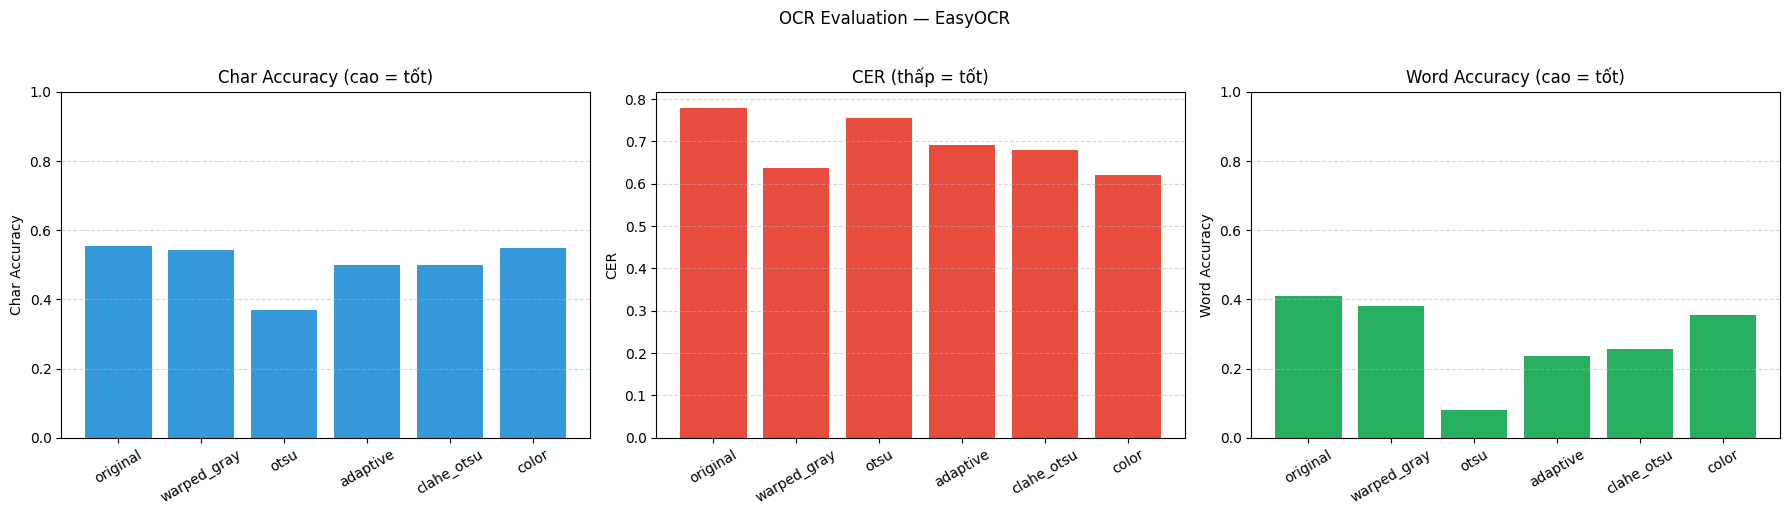

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

summary_idx = summary.set_index('variant').reindex(variant_order)

axes[0].bar(summary_idx.index, summary_idx['char_acc'], color='#3498db')
axes[0].set_title('Char Accuracy (cao = tốt)')
axes[0].set_ylabel('Char Accuracy')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(summary_idx.index, summary_idx['cer'], color='#e74c3c')
axes[1].set_title('CER (thấp = tốt)')
axes[1].set_ylabel('CER')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(summary_idx.index, summary_idx['word_acc'], color='#27ae60')
axes[2].set_title('Word Accuracy (cao = tốt)')
axes[2].set_ylabel('Word Accuracy')
axes[2].set_ylim(0, 1)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('OCR Evaluation — EasyOCR', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 9. Trực quan từng ảnh

6 panel cho 6 variant + in text dự đoán.

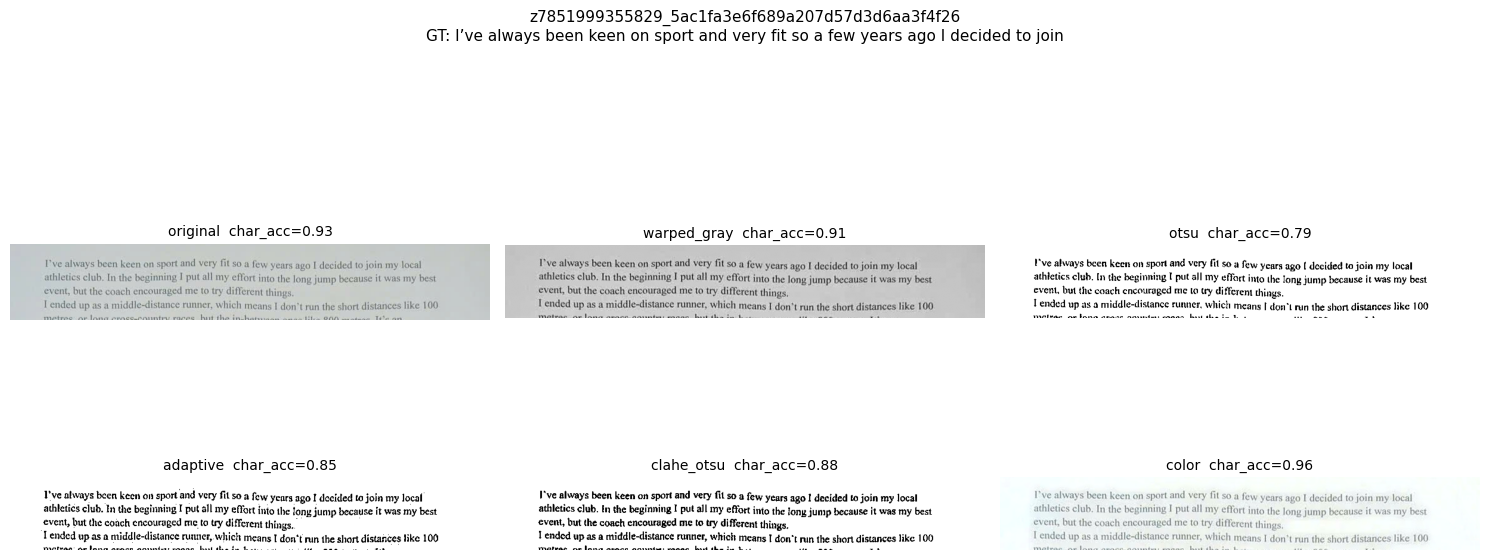

=== z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26 ===
GT  : I’ve always been keen on sport and very fit so a few years ago I decided to join my local athletics club. In the beginning I put all my effort into the long jump becasue it was my best avent, but the coach encouraged me to try different things. I ended up as a middle-distance runner, which means I don’t run the short distances like 100
  original      : Fve ahwvays been on1 sport very fit so few years ago 1 decided to join my local athletics club. In t
  warped_gray   : Fve alwvays been keen on sport and very fit so a years ago decided to join my local athletics club. 
  otsu          : F've always bccn kccn on sport and vcry [il so u few years a80 dccided t0 join my local athlctics cl
  adaptive      : Fve alwvays bccn kccn on sport and very fit s0 a fcw ycars ago dccided l0 joín my local ' athletics 
  clahe_otsu    : I've always keen on sport and very fit s0 a few years ag0 decided lo joín Jocal athletics club_ In t
  col

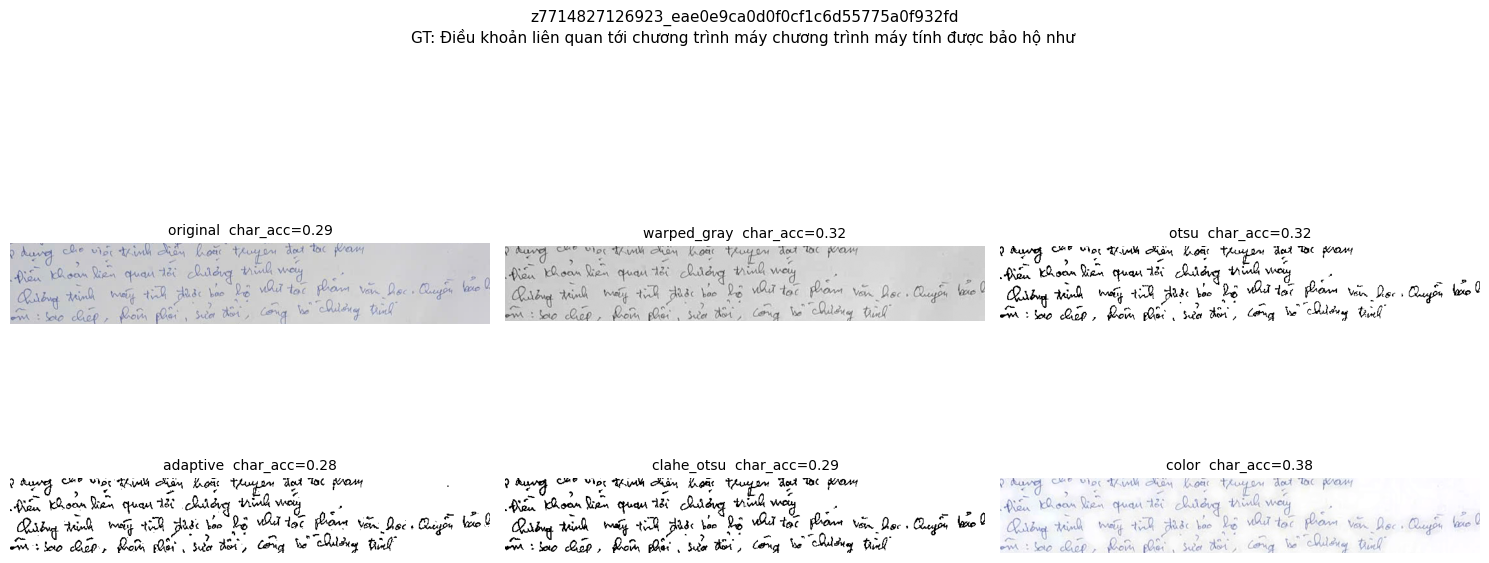

=== z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd ===
GT  : Điều khoản liên quan tới chương trình máy chương trình máy tính được bảo hộ như tác phẩm văn học. Quyền bảo âm: sao chép, phân phối, sửa đổi, công bố chương trình
  original      : (uv @c vìp( liày (oăc teLeu  dat toc pam A2 EQoan Dies ququ VuQ wc 457 da'c bae vQu7 tor Pav Vev [sc
  warped_gray   : 0uo Vic( '#ll out Vi datloc Ma A.eu kaoan Bies quq Aẻi VuQ wcd #7 dudc boc 2G vQj pam Vov Dsc Mo Sao
  otsu          : auvd C Yidl # Lu Voar tule dat Ta( #inm Ai2u kaoan Bies ququ Hẻi "L4 wod nf I7 duJc boo @; v0u +2r p
  adaptive      : aud C #Kml 2444 Mout tulm dal "a( piam A2u kQoan Biec ququ 13i woxd #inq hed +7 dua: Lo R; vMa14 pav
  clahe_otsu    : auvd Cy (wh Mear thutl dat @( paay Ai2u kaoau Bies ququ d}i #ua wed hÁ  t7 dudr bop 2; vQu tor vav @
  color         : 0uo #ul Vi dat o6vam Ai2u }acan Qien ququ -ei wcij Aeimo 4v7 duac boc 2G vQu tr pam Vov Dsc Mao Sao 



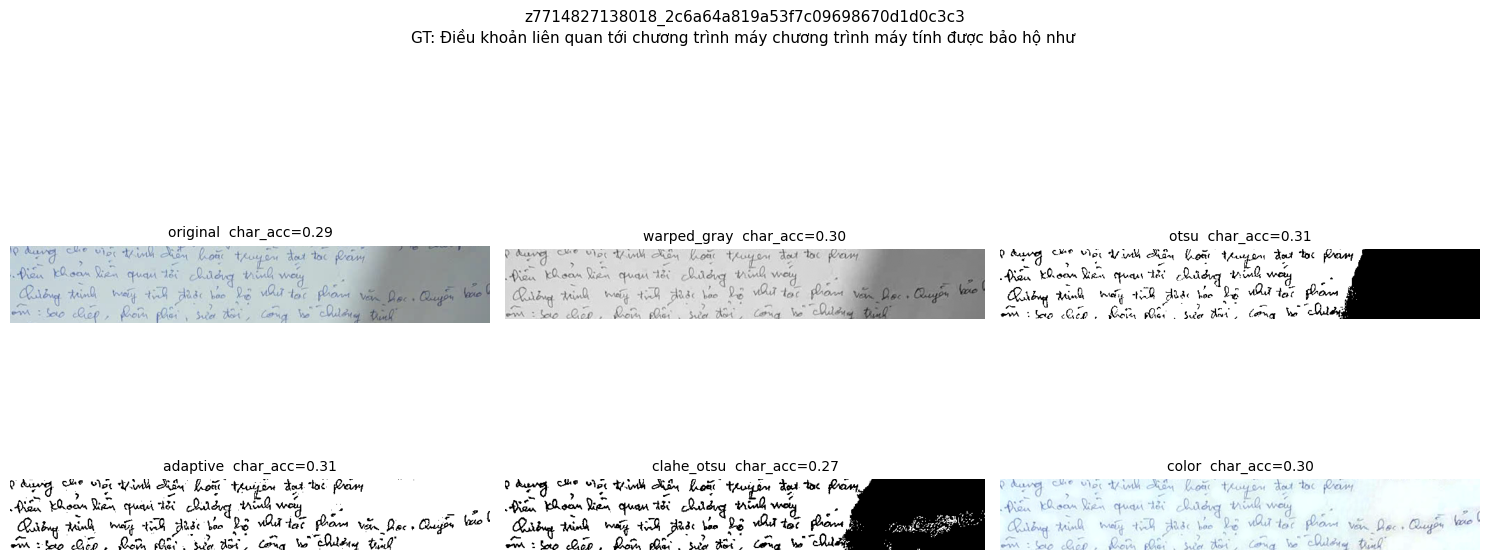

=== z7714827138018_2c6a64a819a53f7c09698670d1d0c3c3 ===
GT  : Điều khoản liên quan tới chương trình máy chương trình máy tính được bảo hộ như tác phẩm văn học. Quyền bảo âm: sao chép, phân phối, sửa đổi, công bố chương trình
  original      : P( #inb _lias {oci e da +oc Qavt 804 Ve qqu 'Iẻi Mncu Ainl 40 dvac Lee Pr vQu7 tor ou Dec kae 5alc L
  warped_gray   : C Vul Voar tE" dat t( Pam 482 Eaoau Rie duqu -ei VEQ wcd 40 d2Ạ6 Lec PG MQu tor Pov Dec bc cQ1zu4 Uo
  otsu          : 'Vib <xian Vosr tKute dat to{ Rxm Aiz xl Re Hai - "LQ wcd h  #J 42  kpc @ c Mlu7 +ar Aam vr Ac; {arn
  adaptive      : uiđ Cy0 vÌpt 'Yinh 2a  Vot   tauijim dad 'bar Rxam Aes }Qaau Bes quaui -ér 444 múf +J dus( Loc 2; lu
  clahe_otsu    : auvd C1e vÌc( +i 881 Koi tufm #a be Mam #a Laoas Qiesququ *i #24wa 444 wad +7 dudt L Qự vBlutr dc( 6
  color         : C Vul 104 Voar tutf dal b( Pam A2 EQoau Rie 4uqu -er VEQ wcd 40 due Loc 2G MQu tor Pov Dsc brc Q1zua



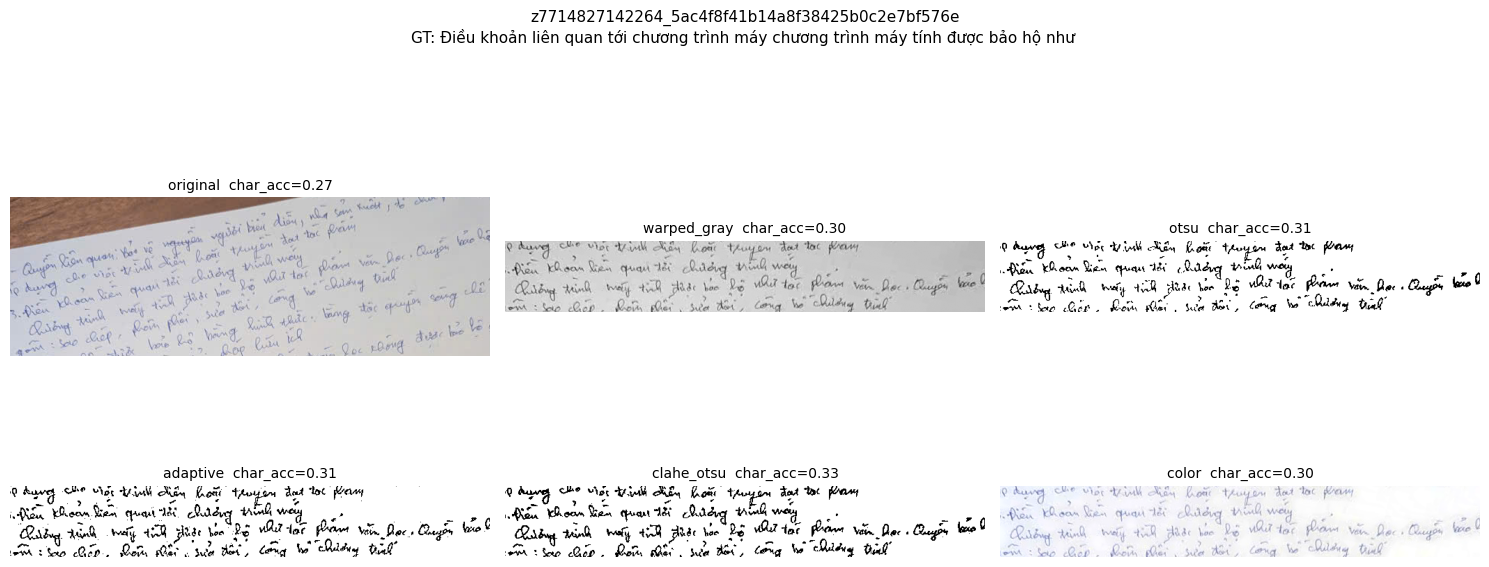

=== z7714827142264_5ac4f8f41b14a8f38425b0c2e7bf576e ===
GT  : Điều khoản liên quan tới chương trình máy chương trình máy tính được bảo hộ như tác phẩm văn học. Quyền bảo âm: sao chép, phân phối, sửa đổi, công bố chương trình
  original      : 54 M84 J}i hen dian Qrev Aal to( brse Cc  Ya 0 Voe ~La 0 wcd Voy~ Qee Caov Qu?v 0.0 "1p{ Qaevg M0Jia
  warped_gray   : Vìt V;u {oà r dat loc Kam Vcu Yl cc 9qu -I; 'Z4 wcd 444 Mef 4,   ;ud boe P; vB.7 lor Fom Vas Dor Vrs
  otsu          : &uv8 €9a viBt #;h 7am Ko9 ta"'9u dat br Kam Piru klocsn Ye  Jqu "; #EQ ed *i4q háf #~B} dzJ6 hec 2s 
  adaptive      : <4$ #auh Chian Kaii taunau dat 'boc Kan Qau }aeas Be^ "W; #24 wea #44 haf duer boo MBul ar {am @iee 
  clahe_otsu    : 0 Vue vIBr #,;h SE Koă dat bt Kam Aien kacan &es Cqu 43 Ys  40 hy t,7 7uat hoc 2ệ vQj t7 Fam vas Bo 
  color         : vViu Voane dat 'loc wa LQ ca Ce 4vqu "Ii L7 *inq 4170 3ad boe Ps MQu tor Fom vay Der Qa Vu Qaevd Qae



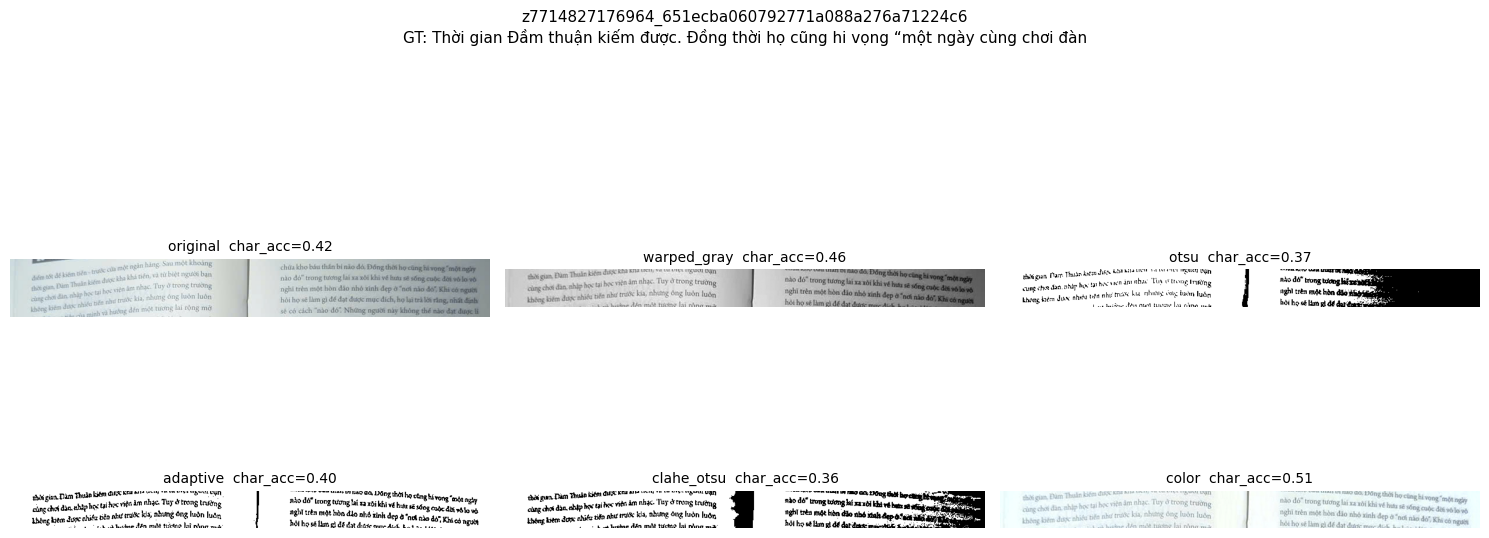

=== z7714827176964_651ecba060792771a088a276a71224c6 ===
GT  : Thời gian Đầm thuận kiếm được. Đồng thời họ cũng hi vọng “một ngày cùng chơi đàn, nhập học tại viện âm nhạc. Tuy ở trong trường nào đó” trong tương lai xa xôi khi về hưu sẽ sống cuộc đời vô lo vô không kiếm được nhiều tiền như trước kia nhưng ông luôn luôn nghĩ một hòn đảo nhỏ xinh đẹp ở “nơi nào đo”. Khi có người hỏi họ sẽ làm gì để đạt được
  original      : truc cra mọt  Sau mot chua kho bau than bi nào da Dóng tha  họ cung hi vong môt ngày Jiem {0 đé kiếm
  warped_gray   : Thuin kiein duoe ) aodo thaicun Dam Men im nhac 'Tuy nao d6" trong twơng lai xa xôi khi veL thởi họ 
  otsu          : Tar Tlada k; .ftis" #i(un iG1 nhilc ndv do' Irong tdooghir huz $ 'n sunc <he É2a. ahaj #k tn nhli ku
  adaptive      : Dim thwlp kiEm difoe: Kha nao d6 toihorung Hvong ~ #igin 'yihoc r*n im nhpc Tuj &trong ndod8* Lai za
  clahe_otsu    : Din Thndp litm dui'| #hàpun 'qiks vitn im nhac. 'Tuj ~ truong n30 d8* tdonghturd Erkaw dJ0, AaPIy #

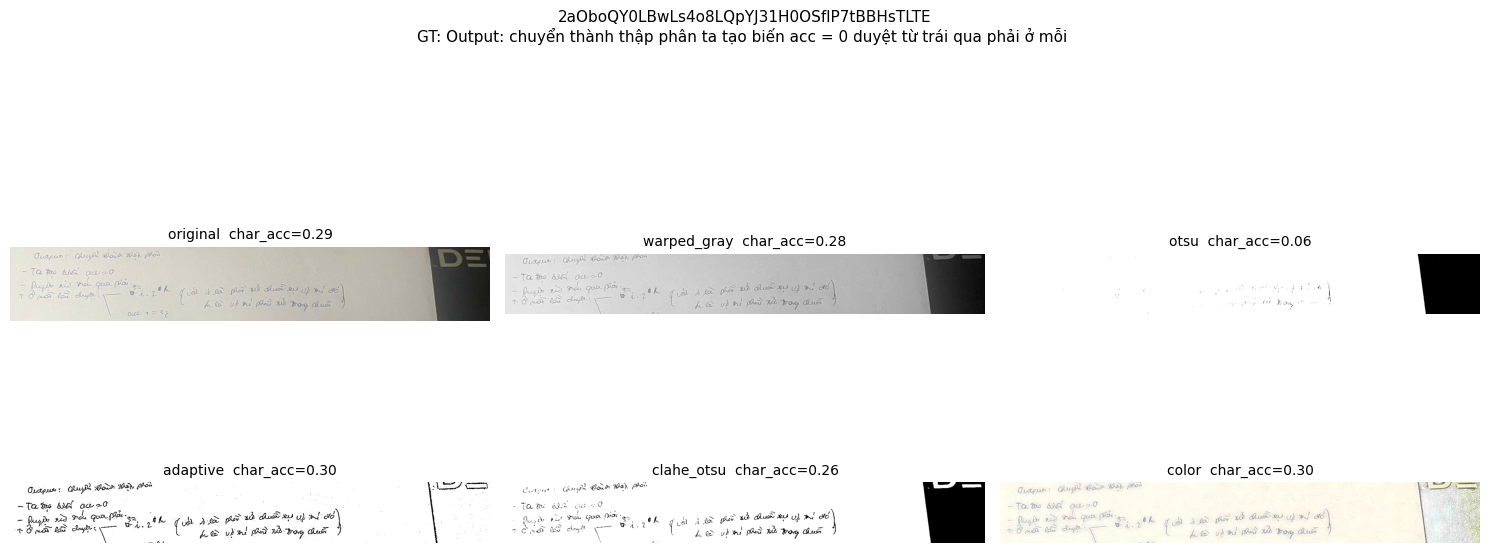

=== 2aOboQY0LBwLs4o8LQpYJ31H0OSflP7tBBHsTLTE ===
GT  : Output: chuyển thành thập phân ta tạo biến acc = 0 duyệt từ trái qua phải ở mỗi lần duyệt
  original      : Gubpuc Cauyp} Xadm }ach {iov D= Ta %c (un Gcl Punà 422 Ylcu qua {at A 4Ỏ duon xu Jau @o Qau clyÈ @. 
  warped_gray   : XQaxd }Mqh {ov Gutp ue Ta Zac  &Ya' Gce 0 422 qcu qua {a. A pov 4Ỏ duos *U u) J 1- 2 ( va À @6o Na c
  otsu          : ; f w&iị
  adaptive      : XOanm 3ao) Pov Outpuo TP: ico Luyd Gci Quv *2 0 a à;@à x 'dud;* u) d8 2 ' aa B ~luyPr; h 0   v) x} p
  clahe_otsu    : CJ - '{QaxD Ha) {Xow (vt ĨQ '?í é; cí: '; 0 2& 2 Yiu 0 k ; @ (n zủ duos *9 U} H ơ 244 0 À . '2 7"0} 
  color         : XQasd Hqh {Aov " Gucp ue To Jc   lun Gcl 0 Quu +22 qcu qua {a. A À @9 pov 48 duos * u} h do @ A 2 @6



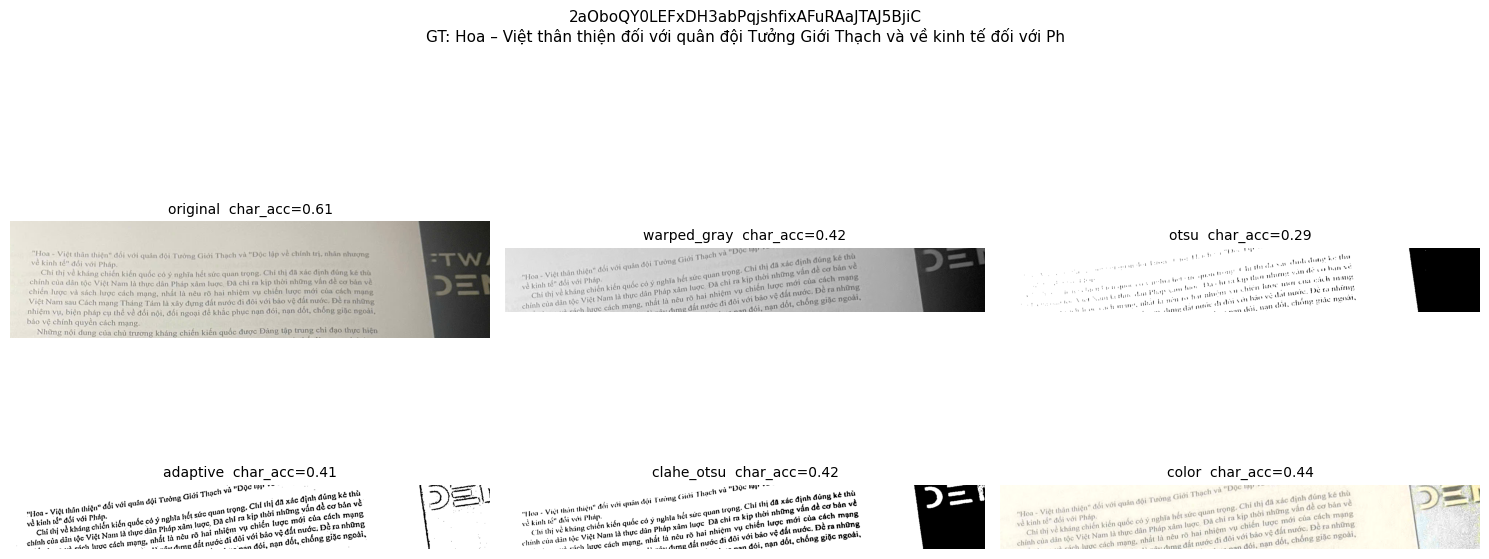

=== 2aOboQY0LEFxDH3abPqjshfixAFuRAaJTAJ5BjiC ===
GT  : Hoa – Việt thân thiện đối với quân đội Tưởng Giới Thạch và về kinh tế đối với Pháp Chỉ thị về kháng chiến kiến quốc có ý nghĩa hết sức quan trọng. Chỉ thị đã xác định đúng kẻ thù chính của dân tộc Việt Nam là thực dan Pháp xâm lược. Đã chỉ ra kịp thời những vấn đề cơ bản về lược cách mạng, nhất là nêu rõ hai nhiệm vụ chiến lược mới của cách mạng đất nước đi đôi với bảo vệ đất nước. Đề ra những đói, nạn dốt, chống giặc ngoài
  original      : "Hon Vỉệt thân thíện" đổỉ vớỉ quân độỉ Tuởngg Gỉởí Thach vủ "Dộc lập vê chinh nhân nhuong vê kinh tế
  warped_gray   : "Dôc IuP vú dộỉ Tưởng thi đã xác đinh đúng bẩr ve 2= thỉện" đổỉ vớỉ trong Chi vấn dè cơ bán "Hon Vảệ
  otsu          : V:1 Il .n0= 2;' (. Iu tu : Ivn + 4 41 ' '11; ulu(1#! ,/1 16' 1/1 4!' Ilu h111,191 141 1,1 I 13 (; I6
  adaptive      : vú "Doc 1w/' 'Tuóng đjnh Qúng kE thỉ ddỉ vJl dội Cll Ij đn xác de cơ bán ve "Hon Việl Ihn (hvídn" nh
  clahe_otsu    : vú "Dýc 141 dội Tuimg (

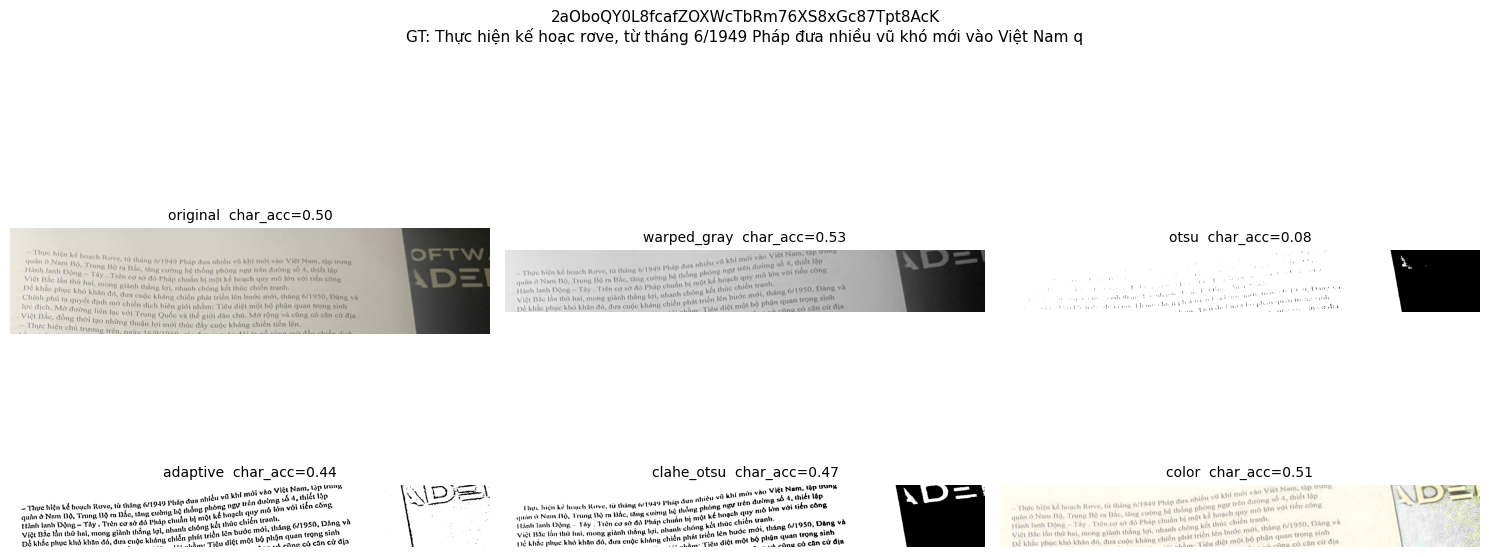

=== 2aOboQY0L8fcafZOXWcTbRm76XS8xGc87Tpt8AcK ===
GT  : Thực hiện kế hoạc rơve, từ tháng 6/1949 Pháp đưa nhiều vũ khó mới vào Việt Nam quân ở Nam Bộ, Trung Bộ ra Bắc, tăng cường hệ thống phòng ngự trên đường số 4, thiết lập Hành lang Đông – Tây. Trên cơ sở đó Pháp chuẩn bị một kế hoạch quy mô lớn với tiến công Việt Bắc lần thứ hai, mong giành thắng lợi, nhanh chóng kết thúc chiến tranh. Để khắc phục khó khăn đó, đưa cuộc kháng chiến phát triển lên bước mới, tháng 6/1950, Đảng và. Tiêu diệt một bộ phận quan trọng sinh có căn cứ địa
  original      : Thurc hỉện ké honeh OfTW quân & Nam Bộ, ur 6/1949 Phảp duu nhỉêu vũ khỉ mởỉ vho Vỉet Nam. Lóp trung 
  warped_gray   : Vist Nam VP Uuny va khl vho 66 thilu Iap Hd= Thurc hỉện ké houch Rove, 1ữ tháng 6/1949 Phẩp dun neu 
  otsu          : 1I 1 . 11 .!:; 1,1 ,ị4''4 17! Hi1 M/1n 1! ' 19.11
  adaptive      : Vlệt Non: Iop Inp val múì váo thllu Wap 6/1949 Phảp dun uen duờng s8 4: 7ne hisn ké husucln Ruve, Iu
  clahe_otsu    : Viei Nam. WP Uronb ví

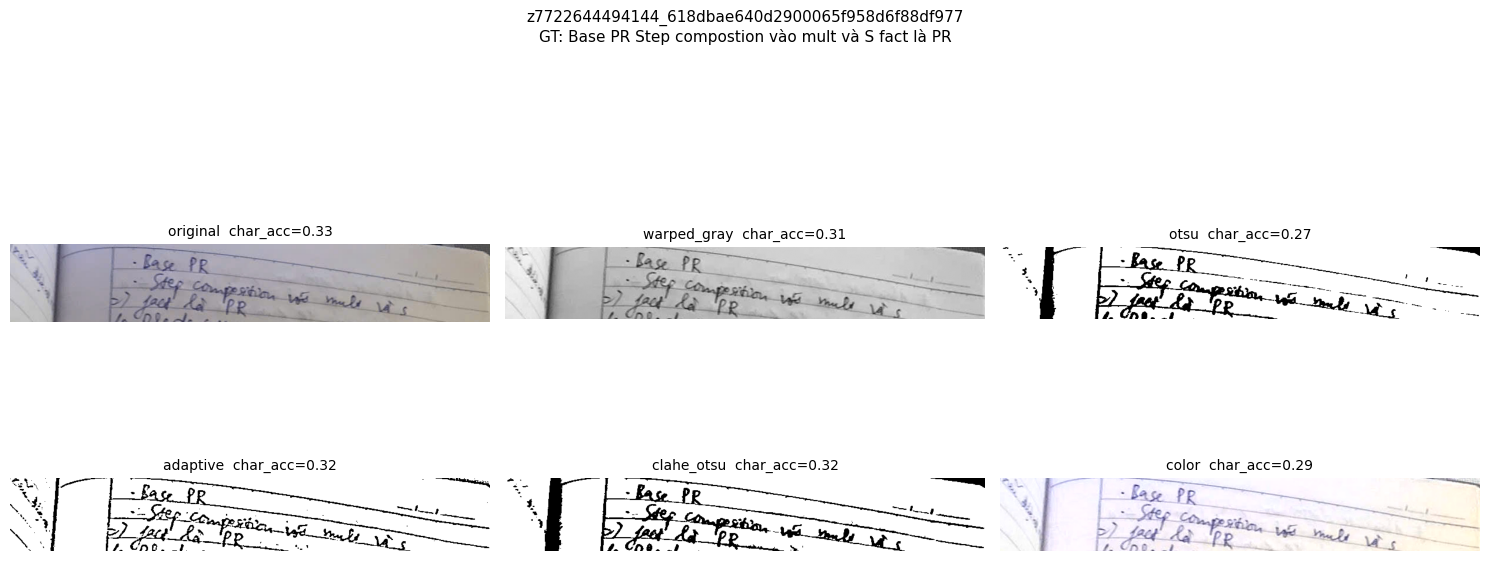

=== z7722644494144_618dbae640d2900065f958d6f88df977 ===
GT  : Base PR Step compostion vào mult và S fact là PR
  original      : Fas Rr S4; Jaa 4a 'Pr 1{ Yl Confexáa
  warped_gray   : r Je4 4a 'Pr 45 my 06 fas S Confesác
  otsu          : PR PP Basc Psbl_MG maal_M
  adaptive      : PR Conie PP hhslu Bas Stef {ácigu
  clahe_otsu    : Pr PR Hl Basc Sospsifa+_L5
  color         : {r 4 Pr 45 Yf 06 fas S+ Confssic au



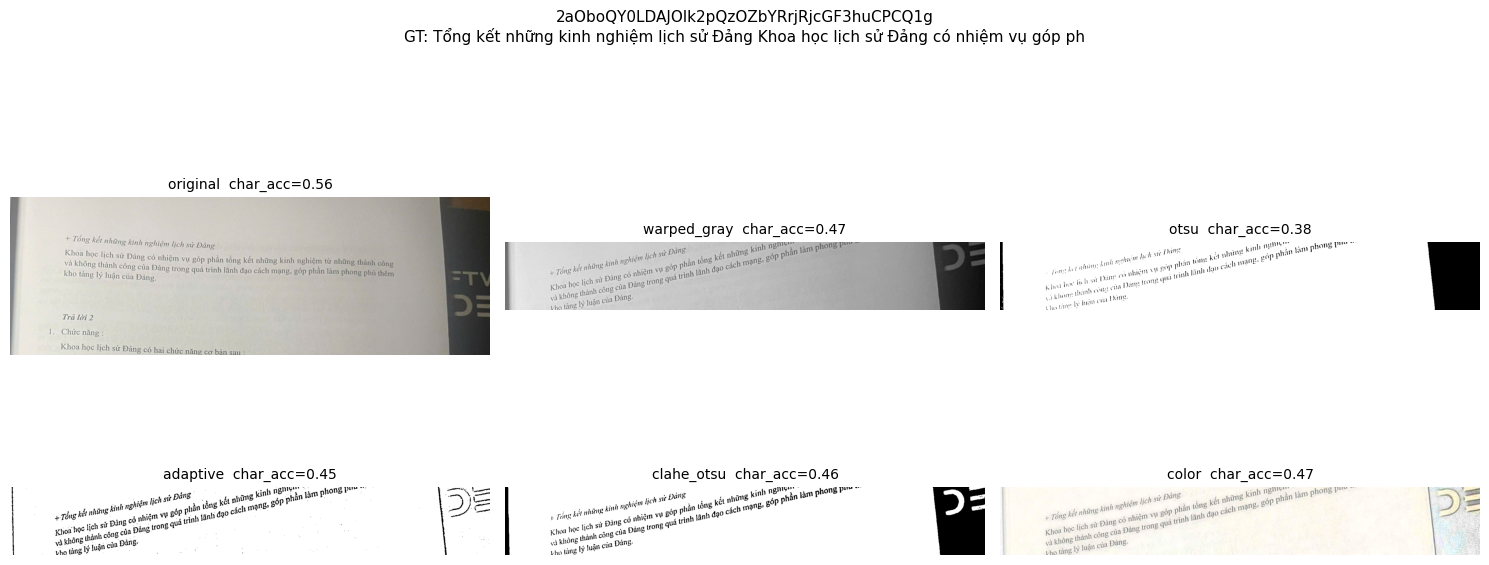

=== 2aOboQY0LDAJOlk2pQzOZbYRrjRjcGF3huCPCQ1g ===
GT  : Tổng kết những kinh nghiệm lịch sử Đảng Khoa học lịch sử Đảng có nhiệm vụ góp phần tổng kết những kinh và không thành công của Đảng trong quá trình lãnh đạo cách mạng, góp phần làm kho tàng lý luận của Đảng
  original      : ket kinh nghiệm lịch sử Khoa hoc ljch sử có nhiệm và thành vụ góp phần kết những kinh nghiệm từ nhữn
  warped_gray   : ngniy < làm phong p< sử Đáng tổng kết góp 2 Tong kết những vụ góp dao ljch sử Đảng có trong hoc cua 
  otsu          : fc { Jảing k lan s1r Inn: kÉl [óp' {ong ho! nhiny 1u dJa} [;im: "1 Iu' Iị I s0 )ảin: Irons khunl (n:
  adaptive      : ngi? , phong Pr" lich sừ Đáng kết góp làm tổng mạng,  Tổug kết những vu lãnli đạo ljch sử Đảng c6 tr
  clahe_otsu    : Đáng ngny , làm phong p < lông kết góp ) Tong kél vu góp dao Ijch sử Đing có trong lnoc Đàng công và
  color         : ngniy < làm phong p< sử Đáng tổng kết góp 2 Tông kết những vu góp dao ljch sử Đảng có trong hoc của 



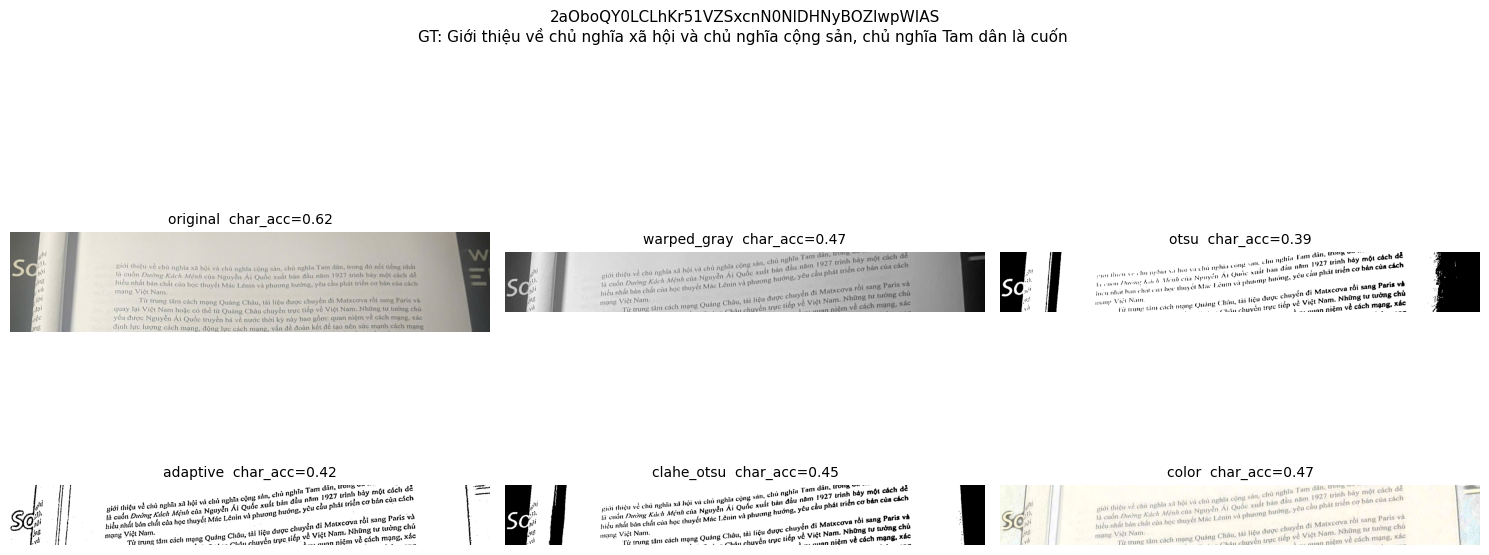

=== 2aOboQY0LCLhKr51VZSxcnN0NlDHNyBOZlwpWIAS ===
GT  : Giới thiệu về chủ nghĩa xã hội và chủ nghĩa cộng sản, chủ nghĩa Tam dân là cuốn Đường Kách Mệnh của Nguyễn Ái Quốc xuất bản đầu năm 1927 trình bày một cách dễ hiểu nhất bản chất của học thuyết Mác Lênin và phương hướng yêu cầu phát triển cơ bản của cách mạng Việt Nam Từ trung tâm cách mạng Quảng Chây, tài liệu được chuyển đi Matxcơva rồi sang Paris và chuyển trực tiếp về Việt Nam. Những tư tưởng chú niệm về cách mạng xác
  original      : W Sci thỉệu về chủ nghvĩ xd hội và clủ nghíA c(ng sủn, chủ Tam dun, trong d6 n8ỉ nhdt hộỉ ld cuon Ká
  warped_gray   : dnns (rong U dé chu Tam trinh bảy một câch xà hộí và chủ nghĩA công bản đầu rien co bán của cach hi 
  otsu          : F:r dín Irong m61 cach dl conk chnn natn 927 trinh bỏy cba cach Jvia Li hnn ch1 nhia Iản dhu co bún 
  adaptive      : Tom dfin, lrong Uy cdcl dé sủn, 1927 uInhi bày m6t xỉ Jnội vh coni Dản đÌu ním co bin cùn li gỉới th
  clahe_otsu    : C Ton dfn (ronb m6l câch d

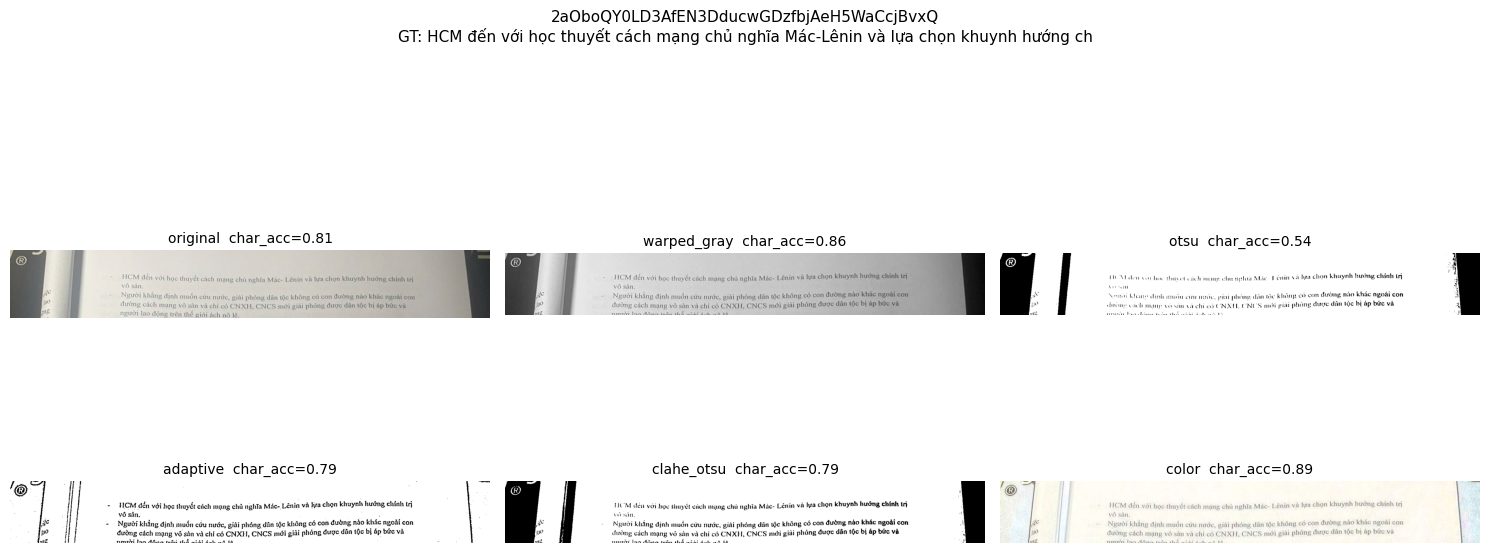

=== 2aOboQY0LD3AfEN3DducwGDzfbjAeH5WaCcjBvxQ ===
GT  : HCM đến với học thuyết cách mạng chủ nghĩa Mác-Lênin và lựa chọn khuynh hướng chính trị vô sản.  Người khẳng định muốn cứu nước, giải phóng dân tộc không có con đường nào khác ngoài con đường cách mạng vô sản và chỉ có CNXH, CNCS mới giải phóng được dân tộc bị áp bức và
  original      : HCM đến vởi học thuyết cách mang chủ Mác - Lênin và lua chon khuynh hướng chính tri vô sẩn cc Ngườỉ 
  warped_gray   : HCM đến vởi học thuyết cách mang chủ nghĩa Mác- Lênin và lya chon khuynh chính tri vô sản. jỆc Ngườỉ
  otsu          : 16 Ml a * (1/ Inn: tlnn. c;ich n04: .:ln mlu; Maie énin à Ny; clgn khuynh huing chínl Iri 11/1 ')1 J
  adaptive      : [ỊCM đén với luọc tluyết cúcl mpng chủ nghia Mác- Lênin và lira clọn kluynl huớng clínl tr vô sản Ng
  clahe_otsu    : I( 'M dén vởi hnoc tlmyét ciicl mng chú nghia Mác - Lênin và Iva chon khuynh huóng chlnh tr I n  iịc
  color         : HCM đến vởi hoc thuyết cách mang chủ nghĩa Mác - Lênin và lya

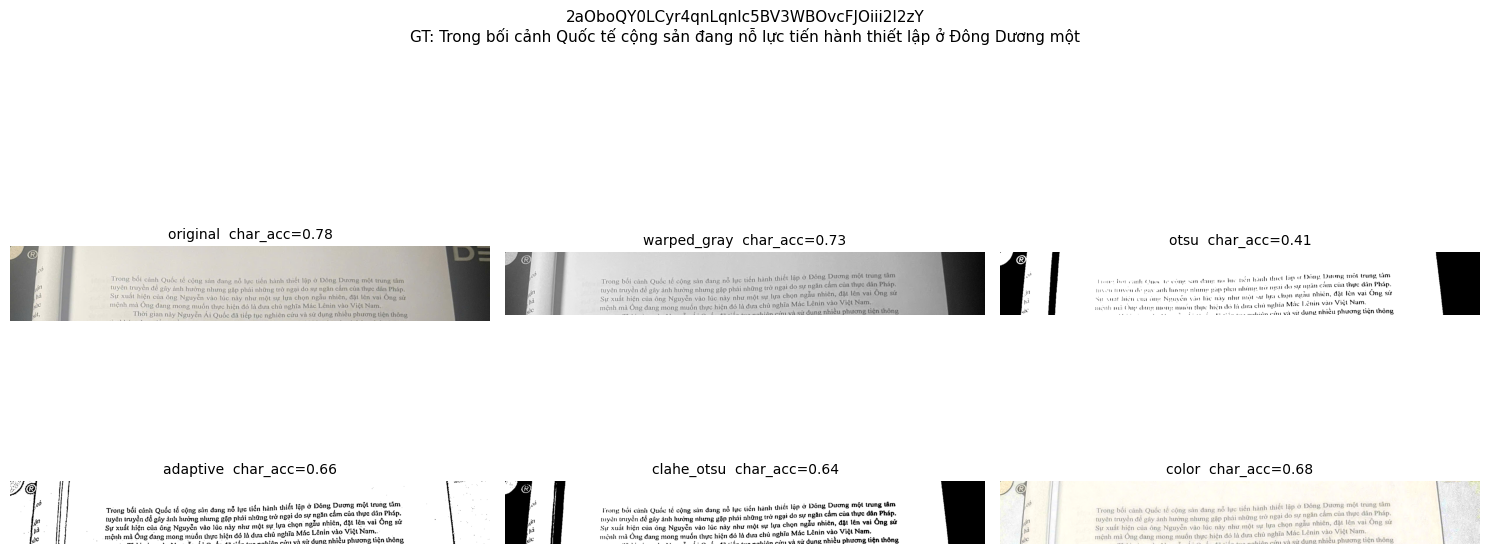

=== 2aOboQY0LCyr4qnLqnlc5BV3WBOvcFJOiii2I2zY ===
GT  : Trong bối cảnh Quốc tế cộng sản đang nỗ lực tiến hành thiết lập ở Đông Dương một trung tâm tuyên truyền để gây ảnh hưởng nhung gặp phải những trở ngại do sự ngăn cấm của thực dân Pháp. Sự xuất hiện của ông Nguyễn vào kucs này như một sự lựa chọn ngẫu nhiên, đặt lên vai Ông sứ mệnh mà Ông đang mong muốn thực hiện đó là đưa chủ nghĩa Mác Lênin vào Vieeth Nam và sử dụng nhiều phương tiện thông
  original      : D bối canh Quốc tế cộng sản nỗ luc tién hành thiết Đông Duong một trung tâm an tuyên truyền để gây ả
  warped_gray   : Trong bối cành Quốc tế cộng sản dang nỗ luc tiến hành thiết lập Đông Duong môt trung tâm trở do sy n
  otsu          : nn hinh Inct lay Dimnp Iuong ti5t Irung lảm 1 (111 1n 11 '1//1 Ih n 80' 601 (a: Mu Iu nnn: Moooi do>
  adaptive      : có 1ế nó . lién hinh tiẾt l#n ớ Dông Duơng mộl Irng tm Trong bối cdnl Quốc cing sản Iuc cam cúa thuc
  clahe_otsu    : Frong bói cànl Quếc té cộng sàn nổ Iuc cién hunh tniét lộ

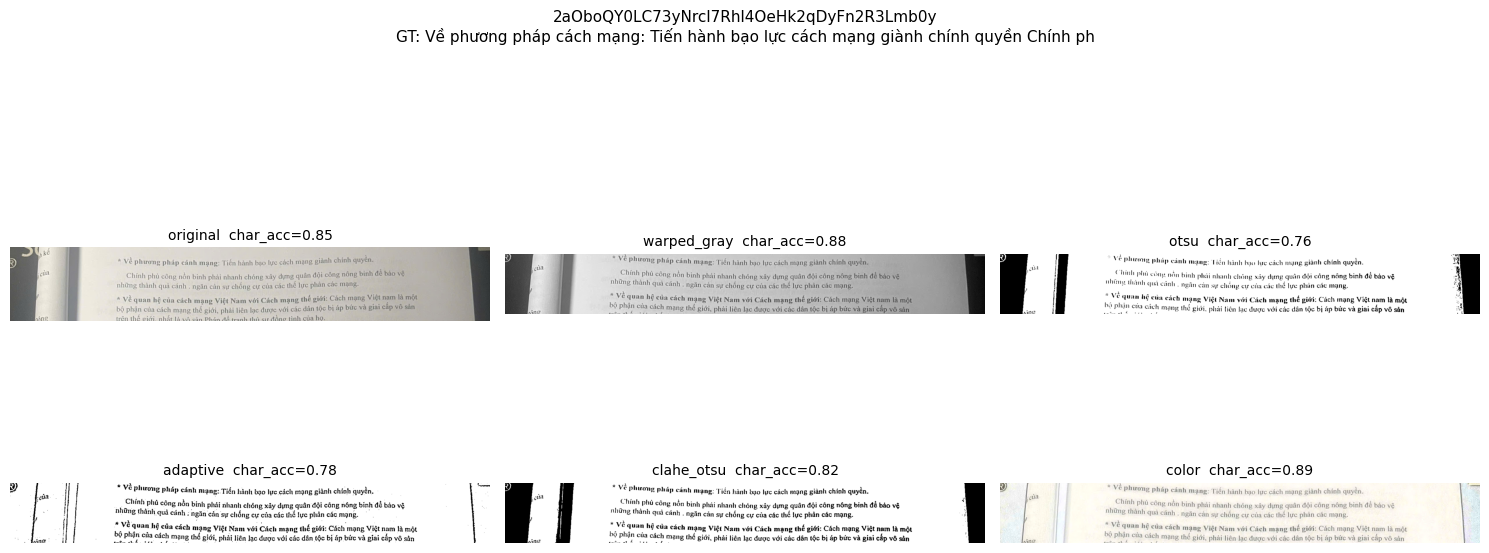

=== 2aOboQY0LC73yNrcl7Rhl4OeHk2qDyFn2R3Lmb0y ===
GT  : Về phương pháp cách mạng: Tiến hành bạo lực cách mạng giành chính quyền Chính phủ công dồ binh phải nhanh chóng xây dựng quân đội công nông binh để bảo vệ những thành quả cánh ngăn cản sự chống cự của các thế lực phản cách mạng Về quan hệ của cách mạng Việt Nam bới Cách mạng thế giới: Cách mạng Việt Nam là một bộ phận của cách mạng thế giới, phải liên tục được với các dân tộc bị áp bức và giai cấp vô sản
  original      : Ohkế Về phưong pháp cánh mạng: Tiến hành bạo lực cách mạng chính cua Chính phủ nổn binh phải nhanh x
  warped_gray   : Về phưong pháp cánh mạng: Tiến hành bao lực cách mang giành chính cúa Chính phủ nồn binh phải nhanh 
  otsu          : và plrong pláp cánl mạnp: Fiên hành lạo lụe cach mung giànl chinh quyèn. 'hinh plnti nẩn binh plui n
  adaptive      : về pưong pláp cánl mạng: Tiến hànl1 bạo lpc cách mang giànl chính 'cua Chínl pl1ủ nồn binl phải nhan
  clahe_otsu    : Về phuong pháp cánh mạng: Tién hànl bạo Ipc

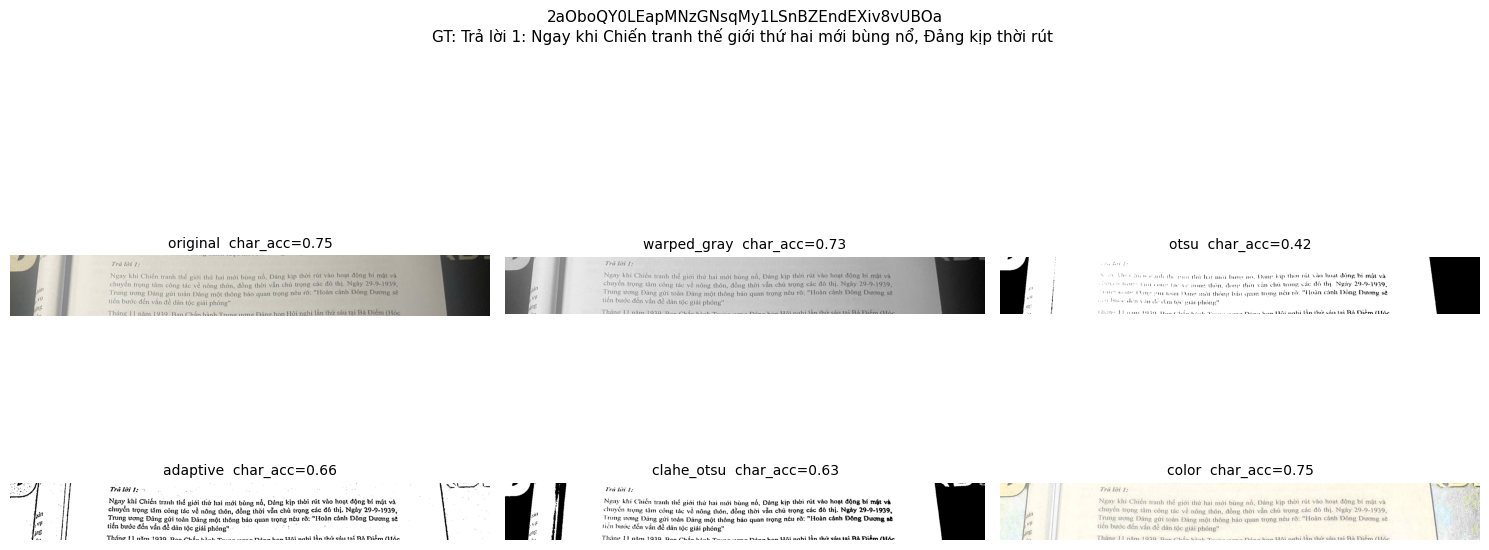

=== 2aOboQY0LEapMNzGNsqMy1LSnBZEndEXiv8vUBOa ===
GT  : Trả lời 1: Ngay khi Chiến tranh thế giới thứ hai mới bùng nổ, Đảng kịp thời rút vào hoạt động bí mật và chuyển trọng tâm công tác về nông thôn, đồng thời vẫn chú trọng các đô thị. Ngày 29-9-1939, trung ương Đảng gửi toàn Đảng một thông báo quan trọng nêu rõ: Hoàn cảnh Đông Dương sẽ tiến bước đến vấn đề dân tộc giải phóng
  original      : Tra lời t : khỉ Chỉến tranh thế gỉới thứ hai mới bùng nổ, Dảng kỉp thờỉ rút vào hoat bí mât va chuyế
  warped_gray   : Iòi I: khỉ Chỉến tranh thế gỉớỉ thứ hai mới nổ, Dáng kip thờỉ rút vào hont bí mât va chuyển trong tâ
  otsu          : 1,'i J+ ! 1111 i: .m1h1 M/1 1{/ / In1 1111 114 7 11   );MW' kif thon rúl ;o Inw'l dong hi mật và (,'
  adaptive      : Trà lài I: Ngay khi Chiến tranln tlé giới tlìứ Jaí n1ới bùng nổ, Dáng kip tl1ởi nit vào hoal động bl
  clahe_otsu    : Iiì khi ( 'hiến tranl tlế giới thứ hai mới nố, Dáng kip thài rút vào hoat đ(ng bl mBt vd Irvng 'âmn 
  color         : Tra lời I

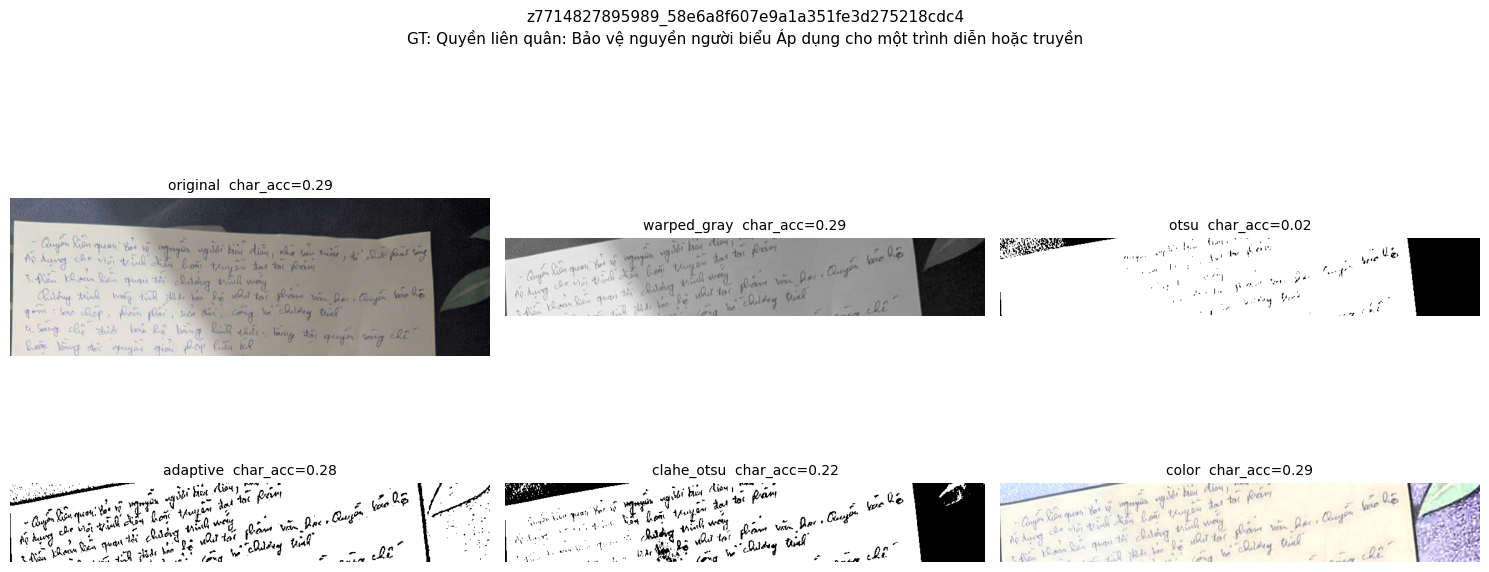

=== z7714827895989_58e6a8f607e9a1a351fe3d275218cdc4 ===
GT  : Quyền liên quân: Bảo vệ nguyền người biểu Áp dụng cho một trình diễn hoặc truyền đạt tác phẩm Điều khoản kiên quan tới chương trình máy được bảo vệ như tác phẩm văn học. Quyền bảo hộ công bố chương trình
  original      : Ga 7u04 ' Y' "7-y01 Het Kacu Dc pa Cor t7ul 28a4 ' @on Ac' tor Qcim 1 Ten Llco @e. ququ H6i "2 wer A
  warped_gray   : isi len   /im4 Qen ~q 'I0 Vuc 6p 6;n Yo' {on 71 we Dec , Clex" 2r v?( Qaenq [om Ma.7 Ior ecv Qent 18
  otsu          : (2 Wr
  adaptive      : òpi' Hua (ioy d0( Q? 8 kae @ }8aman; 8 Q,c Qvy cr 61,} #s Bai v An *448 :ẻ; Qaeiq {af Laerw &ies Bc 
  clahe_otsu    : ibi he {{is4 @ant 40( 06 Y' 40' Yuc ," #v4 Gu A@av VEY Mer 'Quky t' Qf 1av
  color         : Hur tio  86 or Qre} (iệu Yo' Qone @ 012( wed [av Ver Qaenq Maa7 tor Llann Bien 60lav4 "7yc* "E 2u0v 



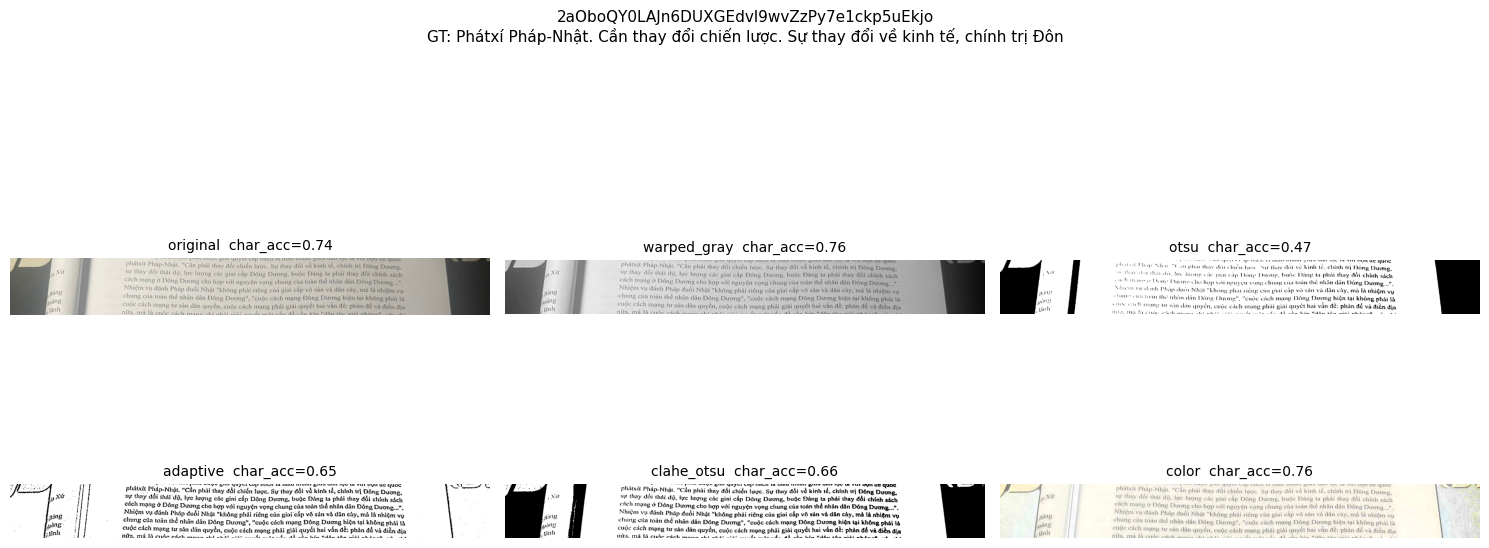

=== 2aOboQY0LAJn6DUXGEdvl9wvZzPy7e1ckp5uEkjo ===
GT  : Phátxí Pháp-Nhật. Cần thay đổi chiến lược. Sự thay đổi về kinh tế, chính trị Đông Dương. Sự thay đổi thái độ, lực lượng các giai cấp Đông Dương, buộc Đảng ta phải thay đổi chính sách cách mạng ở Đông Dương cho hợp với nguyện vọng chưng của toàn thể nhân dân Đông Dương... Nhiệm vụ đánh Pháp đuổi Nhật không phải riêng của giai cấp vô sản và dân cày, mà là nhiệm vụ chung của toàn thể nhân đân Đông Dương, cuộc cách mạng Đông Dương hiện tại không phải là cuộc cách mạng tư sản dân quyền, cuộc cách mạng phải giải quyết hai vấn đề: phản đề và điền địa
  original      : BualquyC Cu acn Bnu un Jon GC quoc phátxít Pháp-Nhật. "Can phảỉ đổỉ chỉén lưvc, Sự thay đổỉ về kỉnh 
  warped_gray   : Jon Ge quoC phátxít Pháp-Nhật. "COn phaỉ đổỉ chỉén Iưvc, Sự thay đổỉ về kỉnh té, chính tri Dưong, W1
  otsu          : quuc }s1/ + 1'1,i1 171 [lu lv; <o Inn Iruf S1 thy soi ve kinh 1 _ chínl tri ;11 } 1, 71 Hu;i1 .6 Iun
  adaptive      : 6 U 4uuc phauxít Pli

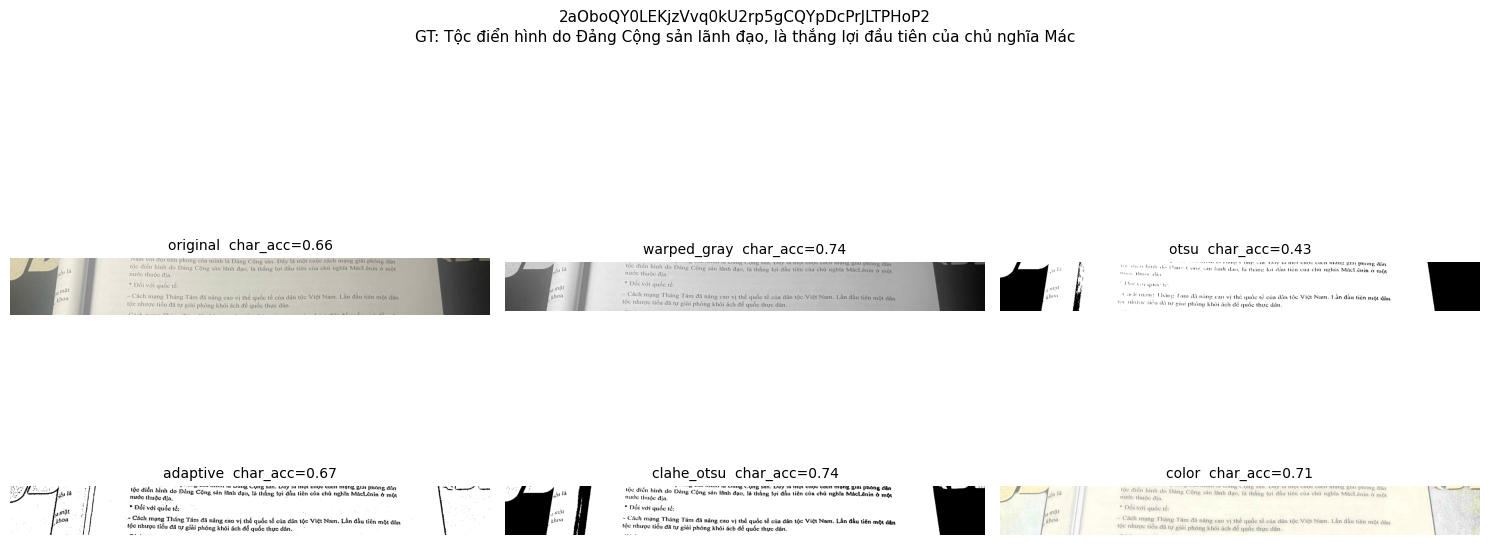

=== 2aOboQY0LEKjzVvq0kU2rp5gCQYpDcPrJLTPHoP2 ===
GT  : Tộc điển hình do Đảng Cộng sản lãnh đạo, là thắng lợi đầu tiên của chủ nghĩa MácLênin ở nước thuộc địa Đối với quốc tế Cách mạng Tháng Tám đã nâng cao vị thế quốc tế của dân tộc Việt Nam. Lần đầu tiên một dân tộc nhược tiểu đã tự giải phòng khỏi ác đế quốc thực dân
  original      : Nam với độỉ tiên phong của minh là sun Đây là môt cuoc cúch mang phóng dân 7 f là tôc dỉển do Cộng s
  warped_gray   : 76 i ane Cong san Day In mot cuoc cach mang glat phóng dnn hjéu là tộc điển hinh do Cộng sản lãnh da
  otsu          : ill ! Vn: 01/1 DJ;y |, 171011 CUVC Coch Maiv #;i phong 'ân hn/ '1,> ' T;t ~n lanh l;n  lảIh;in? loi 
  adaptive      : tộc dỉen hÍnl 6 Uang CYng Sun Duy Iu Invt CUOc cach Mong giuí phóng dan ejéu là do san lanls là Iqi 
  clahe_otsu    : Iộc diẻn 10 dang Cong Son_ Buy 10 mnot Cuyc cach MonB Biuí phóng dAn ju là hinh do Cộng sdn Iãnl1 đạ
  color         : tôc 6 ane Cong san Day In mot cuoc cach mang glai phóng dân heu là

In [16]:
for stem, cache in predictions_cache.items():
    crops = cache['crops']
    preds = cache['preds']
    gt_text = items[stem]['ground_truth']

    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    axes = axes.flatten()

    for ax, variant in zip(axes, ALL_VARIANTS):
        img = crops.get(variant)
        if img is None or img.size == 0:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
            ax.axis('off')
            continue
        if len(img.shape) == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        row = df[(df['stem'] == stem) & (df['variant'] == variant)]
        acc = row['char_acc'].iloc[0] if len(row) else 0.0
        ax.set_title(f'{variant}  char_acc={acc:.2f}', fontsize=10)
        ax.axis('off')

    plt.suptitle(f'{stem}\nGT: {gt_text[:80]}', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f'=== {stem} ===')
    print(f'GT  : {gt_text}')
    for variant in ALL_VARIANTS:
        pred = preds.get(variant, '').strip().replace('\n', ' | ')
        print(f'  {variant:14s}: {pred[:100]}')
    print()

## 10. Merge với kết quả với Tesseract


In [19]:
summary_paths = [
    EVAL_DIR / 'ocr_summary_tesseract.csv',
    EVAL_DIR / 'ocr_summary_easyocr.csv',
]

frames = []
for p in summary_paths:
    if p.exists():
        temp = pd.read_csv(p)
        frames.append(temp)
        print(f'Đã đọc: {p.name}')
    else:
        print(f'Chưa có: {p.name}')

if frames:
    merged = pd.concat(frames, ignore_index=True)
    merged = merged.drop_duplicates(subset=['engine', 'variant'], keep='last')

    pivot_char = merged.pivot(index='variant', columns='engine', values='char_acc').reindex(variant_order)
    pivot_cer = merged.pivot(index='variant', columns='engine', values='cer').reindex(variant_order)
    pivot_word = merged.pivot(index='variant', columns='engine', values='word_acc').reindex(variant_order)

    print('\nChar Accuracy (cao = tốt):')
    display(pivot_char.round(4))

    print('\nCER (thấp = tốt):')
    display(pivot_cer.round(4))

    print('\nWord Accuracy (cao = tốt):')
    display(pivot_word.round(4))

    merged.to_csv(EVAL_DIR / 'ocr_summary_combined.csv', index=False)
    print(f'\nLưu combined → {EVAL_DIR / "ocr_summary_combined.csv"}')
else:
    print('Chưa có file summary nào để merge.')


Đã đọc: ocr_summary_tesseract.csv
Đã đọc: ocr_summary_easyocr.csv

Char Accuracy (cao = tốt):


engine,easyocr,tesseract
variant,,
original,0.5556,0.5218
warped_gray,0.5432,0.5914
otsu,0.3687,0.5124
adaptive,0.4989,0.6122
clahe_otsu,0.5006,0.6120
color,0.5489,0.6030



CER (thấp = tốt):


engine,easyocr,tesseract
variant,,
original,0.7783,0.8133
warped_gray,0.6370,0.5401
otsu,0.7555,0.6270
adaptive,0.6924,0.6054
clahe_otsu,0.6806,0.5604
color,0.6213,0.6241



Word Accuracy (cao = tốt):


engine,easyocr,tesseract
variant,,
original,0.4094,0.4493
warped_gray,0.3823,0.4342
otsu,0.0791,0.2627
adaptive,0.2361,0.4596
clahe_otsu,0.2566,0.4760
color,0.3545,0.4885



Lưu combined → /content/drive/MyDrive/CV/pr/dataset/test/eval_run/ocr_summary_combined.csv
